# Day 1｜AI 全域市場需求預測與動態商情分析

## 從市場訊號到可驗證需求預測

> **資料使用邊界：** 本 Notebook 使用固定亂數種子產生的教學虛擬資料，不是任何企業的真實營運資料。結果只能用於練習分析流程，不可宣稱為企業事實或因果效果。

### 故事情境

週一早上，四家企業同時收到一封主管來信：雜草町想知道哪種手作課值得加開；義大要判斷哪種度假套票有成長機會；盛香珍要選出下一個小泡芙主打方向；寶島眼鏡要看哪種商品／服務需求正在升溫。主管沒有給答案，只交付兩年虛擬市場訊號，要求今天下班前提出『先做哪一項、預測誤差多大、還要補什麼資料』。

### 今日決策問題

**哪一個商品或服務值得優先驗證需求，而且證據與預測誤差是否足以支持下一步？**

### 學習目標

- 能區分描述、預測與因果問題
- 能完成資料品質檢查與市場趨勢視覺化
- 能以時間先後切分資料建立可解釋 baseline
- 能用 MAE、RMSE、R² 解讀預測表現
- 能把結果翻譯成含限制的企業決策

### Colab 操作提醒

1. 在 Google Drive 建立個人副本。
2. 將對應 CSV 上傳到 Colab `/content`，或保持教材包原始相對路徑。
3. 由上到下依序執行；若 Runtime 重啟，請重新執行全部儲存格。
4. 每個程式碼儲存格後都有繁體中文說明、預期輸出與完成檢核。

### [D1-S01] 載入資料並確認分析任務

In [1]:
# 本格目的：載入套件並找到教學資料檔
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid")

# 優先從公開 GitHub Raw 讀取資料；失敗時再使用 /content 或本機相對路徑
import os

RAW_DATA_URL = "https://raw.githubusercontent.com/johnnychao/mcut-m4-business-analytics-2026-student/main/docs/resources/data/day-1-market-demand.csv"
DATA_FILENAME = "day-1-market-demand.csv"
LOCAL_FALLBACK_NAMES = [DATA_FILENAME, "day1_market_demand_signals.csv"]
FORCE_LOCAL_DATA = os.environ.get("M4_FORCE_LOCAL_DATA") == "1"

try:
    # 正式教材 QA 會刻意關閉遠端來源，確認 ../04_data 備援路徑可獨立運作
    if FORCE_LOCAL_DATA:
        raise ConnectionError("M4 Notebook QA：改用本機資料備援")
    df = pd.read_csv(RAW_DATA_URL)
    data_source = RAW_DATA_URL
except Exception as remote_error:
    candidate_paths = []
    for filename in LOCAL_FALLBACK_NAMES:
        candidate_paths.extend([
            Path("/content") / filename,
            Path(filename),
            Path("../04_data") / filename,
            Path("../04_虛擬資料") / filename,
        ])
    data_path = next((path for path in candidate_paths if path.exists()), None)
    if data_path is None:
        raise FileNotFoundError(
            f"GitHub Raw 暫時無法讀取，而且 /content 也找不到 {DATA_FILENAME}。"
        ) from remote_error
    df = pd.read_csv(data_path)
    data_source = str(data_path)

# 所有課堂匯出檔集中放在 outputs，避免散落在 Notebook 旁
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"資料來源：{data_source}")
print(f"資料尺寸：{df.shape}")
display(df.head(3))

資料來源：..\04_data\day-1-market-demand.csv
資料尺寸：(384, 12)


,date,company,offer,search_index,social_mentions,website_visits,promo_spend,price_index,competitor_index,holiday_flag,demand_units,is_synthetic
0,2024-01-01,雜草町,手捏陶體驗,58.600,107.000,"1,403.000","2,057.000",1.070,51.300,1,117,True
1,2024-02-01,雜草町,手捏陶體驗,50.300,88.000,"1,075.000","2,284.000",0.972,42.900,1,110,True
2,2024-03-01,雜草町,手捏陶體驗,53.100,51.000,"1,275.000","1,574.000",0.940,36.500,0,98,True


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 載入常用分析套件，依序尋找 Colab 或教材包中的 CSV，並預覽前三列。
- **預期輸出：** 顯示資料路徑、資料尺寸與三筆資料。
- **完成檢核：** `is_synthetic` 欄位存在，而且所有值均為 True。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D1-S02] 檢查日期、缺失與重複主鍵

In [2]:
# 本格目的：確認資料邊界、型態、缺失與重複狀況
assert "is_synthetic" in df.columns, "缺少虛擬資料標記欄位"
assert df["is_synthetic"].astype(str).str.lower().eq("true").all(), "資料中出現非虛擬標記"

df["date"] = pd.to_datetime(df["date"], errors="coerce")
quality_report = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique": df.nunique(dropna=False),
})
duplicate_count = df.duplicated(subset=["date", "company", "offer"]).sum()
print(f"日期範圍：{df['date'].min().date()} 到 {df['date'].max().date()}")
print(f"重複主鍵筆數：{duplicate_count}")
display(quality_report)

# 建模前只補數值特徵缺失；目標 demand_units 不可隨意補造
for col in ["social_mentions", "website_visits"]:
    df[col] = df.groupby("company")[col].transform(lambda s: s.fillna(s.median()))

日期範圍：2024-01-01 到 2025-12-01
重複主鍵筆數：0


,dtype,missing,unique
date,datetime64[us],0,24
company,str,0,4
offer,str,0,16
search_index,float64,0,261
social_mentions,float64,4,124
website_visits,float64,4,361
promo_spend,float64,0,377
price_index,float64,0,182
competitor_index,float64,0,266
holiday_flag,int64,0,2


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 確認日期、缺失、唯一值與重複主鍵，再以企業中位數處理兩個教學用缺失欄位。
- **預期輸出：** 品質表中可看到原始缺失；補值後兩欄缺失為 0。
- **完成檢核：** `duplicate_count` 為 0，且 `demand_units` 沒有缺值。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D1-S03] 選定企業並建立描述統計

In [3]:
# 本格目的：只分析一家公司，避免把不同量級混在同一模型
# TODO：請改成你組負責的企業名稱
SELECTED_COMPANY = "雜草町"

print("可選企業：", df["company"].unique().tolist())
company_df = df.loc[df["company"] == SELECTED_COMPANY].copy()
assert not company_df.empty, "企業名稱不正確，請從可選企業清單複製"
assert company_df["company"].nunique() == 1

offer_summary = company_df.groupby("offer").agg(
    months=("date", "nunique"),
    mean_demand=("demand_units", "mean"),
    demand_std=("demand_units", "std"),
    mean_search=("search_index", "mean"),
    total_promo=("promo_spend", "sum"),
).sort_values("mean_demand", ascending=False)
display(offer_summary.round(2))

可選企業： ['雜草町', '義大開發', '盛香珍X亙美質珍', '寶島眼鏡']


,months,mean_demand,demand_std,mean_search,total_promo
offer,,,,,
老宅夜間工藝,24,124.580,10.670,71.800,"40,463.000"
金工入門,24,119.920,12.310,67.820,"42,518.000"
羊毛氈課程,24,110.080,11.370,58.700,"41,049.000"
手捏陶體驗,24,101.460,11.960,52.080,"41,064.000"


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 修改一個參數即可切換企業，並比較各商品／服務的平均需求、波動與市場訊號。
- **預期輸出：** 四個商品／服務的摘要表。
- **完成檢核：** 表格只有一家企業，且每個 offer 都有 24 個月份。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D1-S04] 畫出月需求與三月移動平均

C:\Users\enentutor\AppData\Local\Temp\ipykernel_13596\3884500404.py:16: UserWarning: Glyph 38620 (\N{CJK UNIFIED IDEOGRAPH-96DC}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\enentutor\AppData\Local\Temp\ipykernel_13596\3884500404.py:16: UserWarning: Glyph 33609 (\N{CJK UNIFIED IDEOGRAPH-8349}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\enentutor\AppData\Local\Temp\ipykernel_13596\3884500404.py:16: UserWarning: Glyph 30010 (\N{CJK UNIFIED IDEOGRAPH-753A}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\enentutor\Desktop\AI_Projects\03_Teaching_教學課程\明志科技大學數據商業分析模組\AI驅動產品創新與市場應用培訓班\tools\m4_colab_package_builder\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38620 (\N{CJK UNIFIED IDEOGRAPH-96DC}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\enentutor\Desktop\AI_Projects\03_Teaching_教學課程\明志科技大學數據商業分析模組\AI驅動產品創新與市場應用培訓班\tools\m4_colab_package_builder\.venv\Lib\site-packages\IPython\core\pyla

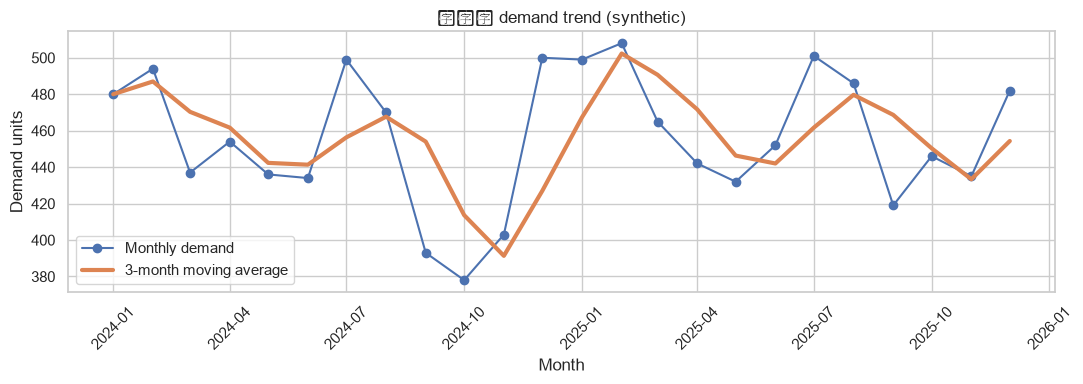

C:\Users\enentutor\AppData\Local\Temp\ipykernel_13596\3884500404.py:19: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(monthly.tail(6).round(1))


,date,demand_units,search_index,website_visits,demand_ma3
18,2025-07-01,501,69.000,"6,056.000",461.700
19,2025-08-01,486,67.400,"6,086.000",479.700
20,2025-09-01,419,61.800,"5,111.000",468.700
21,2025-10-01,446,58.200,"5,407.000",450.300
22,2025-11-01,435,59.100,"5,188.000",433.300
23,2025-12-01,482,72.000,"6,316.000",454.300


In [4]:
# 本格目的：先觀察時間趨勢，再決定是否需要預測模型
monthly = company_df.groupby("date", as_index=False).agg(
    demand_units=("demand_units", "sum"),
    search_index=("search_index", "mean"),
    website_visits=("website_visits", "sum"),
)
monthly = monthly.sort_values("date")
monthly["demand_ma3"] = monthly["demand_units"].rolling(3, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(monthly["date"], monthly["demand_units"], marker="o", label="Monthly demand")
ax.plot(monthly["date"], monthly["demand_ma3"], linewidth=3, label="3-month moving average")
ax.set(title=f"{SELECTED_COMPANY} demand trend (synthetic)", xlabel="Month", ylabel="Demand units")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(monthly.tail(6).round(1))

#### 程式碼說明（繁體中文）

- **這段做了什麼：** 將企業各商品需求加總成月總量，並用三月移動平均降低短期噪音。
- **預期輸出：** 一張需求趨勢圖及最近六個月表格。
- **完成檢核：** 日期依序排列；圖表不能被解讀成任何真實企業趨勢。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D1-S05] 檢查數值關聯並守住因果邊界

,correlation
demand_units,1.000
search_index,0.812
website_visits,0.763
social_mentions,0.717
holiday_flag,0.524
promo_spend,0.402
price_index,0.294
competitor_index,-0.057


C:\Users\enentutor\AppData\Local\Temp\ipykernel_13596\2490241656.py:12: UserWarning: Glyph 38620 (\N{CJK UNIFIED IDEOGRAPH-96DC}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\enentutor\AppData\Local\Temp\ipykernel_13596\2490241656.py:12: UserWarning: Glyph 33609 (\N{CJK UNIFIED IDEOGRAPH-8349}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\enentutor\AppData\Local\Temp\ipykernel_13596\2490241656.py:12: UserWarning: Glyph 30010 (\N{CJK UNIFIED IDEOGRAPH-753A}) missing from font(s) Arial.
  plt.tight_layout()


C:\Users\enentutor\Desktop\AI_Projects\03_Teaching_教學課程\明志科技大學數據商業分析模組\AI驅動產品創新與市場應用培訓班\tools\m4_colab_package_builder\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38620 (\N{CJK UNIFIED IDEOGRAPH-96DC}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\enentutor\Desktop\AI_Projects\03_Teaching_教學課程\明志科技大學數據商業分析模組\AI驅動產品創新與市場應用培訓班\tools\m4_colab_package_builder\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 33609 (\N{CJK UNIFIED IDEOGRAPH-8349}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\enentutor\Desktop\AI_Projects\03_Teaching_教學課程\明志科技大學數據商業分析模組\AI驅動產品創新與市場應用培訓班\tools\m4_colab_package_builder\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30010 (\N{CJK UNIFIED IDEOGRAPH-753A}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


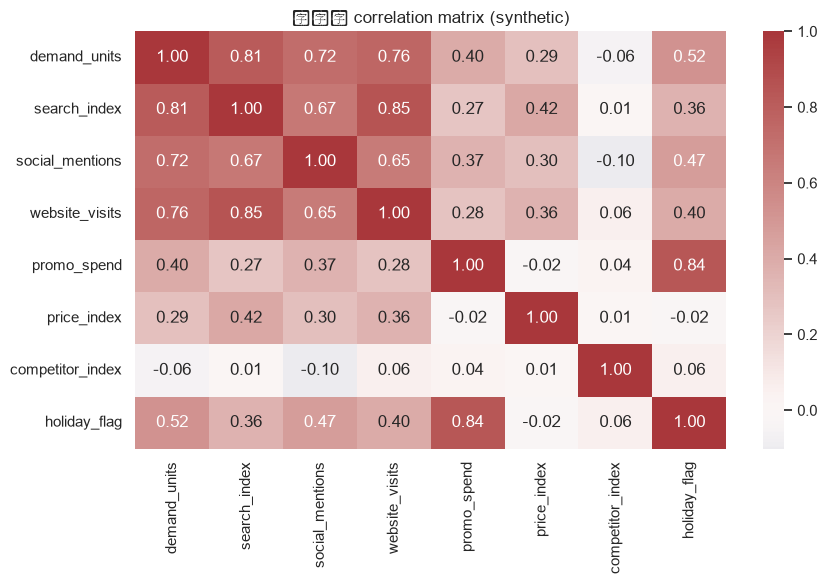

固定句型：在此虛擬資料中，部分市場訊號與需求呈關聯；這不表示訊號造成需求改變。


In [5]:
# 本格目的：找出與需求共同變動的市場訊號，但不做因果宣稱
numeric_cols = [
    "demand_units", "search_index", "social_mentions", "website_visits",
    "promo_spend", "price_index", "competitor_index", "holiday_flag",
]
corr = company_df[numeric_cols].corr()
display(corr["demand_units"].sort_values(ascending=False).to_frame("correlation"))

plt.figure(figsize=(9, 6))
sns.heatmap(corr, cmap="vlag", center=0, annot=True, fmt=".2f")
plt.title(f"{SELECTED_COMPANY} correlation matrix (synthetic)")
plt.tight_layout()
plt.show()

print("固定句型：在此虛擬資料中，部分市場訊號與需求呈關聯；這不表示訊號造成需求改變。")

#### 程式碼說明（繁體中文）

- **這段做了什麼：** 計算數值欄位相關係數並用熱圖呈現；相關只用於探索。
- **預期輸出：** 需求相關排序與相關矩陣。
- **完成檢核：** 口頭與書面結論均使用『呈關聯』，不得寫『造成』。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D1-S06] 建立時間切分與 naive baseline

In [6]:
# 本格目的：用較早資料訓練、較晚資料測試，避免提前看見未來
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_df = company_df.sort_values(["date", "offer"]).copy()
model_df["naive_prediction"] = model_df.groupby("offer")["demand_units"].shift(1)
unique_dates = np.array(sorted(model_df["date"].dropna().unique()))
cutoff_date = unique_dates[int(len(unique_dates) * 0.80)]
train_df = model_df.loc[model_df["date"] < cutoff_date].copy()
test_df = model_df.loc[model_df["date"] >= cutoff_date].dropna(subset=["naive_prediction"]).copy()

naive_mae = mean_absolute_error(test_df["demand_units"], test_df["naive_prediction"])
print(f"切分日期：{pd.Timestamp(cutoff_date).date()}")
print(f"訓練筆數：{len(train_df)}；測試筆數：{len(test_df)}")
print(f"Naive baseline MAE：{naive_mae:,.2f} 需求單位")

切分日期：2025-08-01
訓練筆數：76；測試筆數：20
Naive baseline MAE：10.35 需求單位


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 依時間先後切分資料，並以『同商品上月需求』作為簡單基準。
- **預期輸出：** 切分日期、訓練／測試筆數與 baseline MAE。
- **完成檢核：** 訓練日期全部早於測試日期；沒有隨機打散時間。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D1-S07] 建立可重現的線性迴歸 Pipeline

In [7]:
# 本格目的：把數值與商品類別放入同一個可重現預測流程
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = [
    "search_index", "social_mentions", "website_visits", "promo_spend",
    "price_index", "competitor_index", "holiday_flag",
]
categorical_features = ["offer"]
preprocess = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])
model = Pipeline([("preprocess", preprocess), ("model", LinearRegression())])

X_train = train_df[numeric_features + categorical_features]
y_train = train_df["demand_units"]
X_test = test_df[numeric_features + categorical_features]
y_test = test_df["demand_units"]
model.fit(X_train, y_train)
test_df["model_prediction"] = np.maximum(0, model.predict(X_test))
print("模型已完成訓練。")

模型已完成訓練。


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 在 Pipeline 內完成補值、標準化、類別編碼與線性迴歸；測試資料不參與 fit。
- **預期輸出：** 顯示模型完成訓練，並在測試資料新增預測欄。
- **完成檢核：** 特徵清單沒有 `demand_units` 的未來值或任何測試答案。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D1-S08] 比較 baseline 與線性迴歸

,model,MAE,RMSE,R2
0,Naive: previous month,10.350,13.782,-0.013
1,Linear regression,6.320,7.712,0.683


C:\Users\enentutor\AppData\Local\Temp\ipykernel_13596\3483952351.py:24: UserWarning: Glyph 38620 (\N{CJK UNIFIED IDEOGRAPH-96DC}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\enentutor\AppData\Local\Temp\ipykernel_13596\3483952351.py:24: UserWarning: Glyph 33609 (\N{CJK UNIFIED IDEOGRAPH-8349}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\enentutor\AppData\Local\Temp\ipykernel_13596\3483952351.py:24: UserWarning: Glyph 30010 (\N{CJK UNIFIED IDEOGRAPH-753A}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\enentutor\Desktop\AI_Projects\03_Teaching_教學課程\明志科技大學數據商業分析模組\AI驅動產品創新與市場應用培訓班\tools\m4_colab_package_builder\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38620 (\N{CJK UNIFIED IDEOGRAPH-96DC}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\enentutor\Desktop\AI_Projects\03_Teaching_教學課程\明志科技大學數據商業分析模組\AI驅動產品創新與市場應用培訓班\tools\m4_colab_package_builder\.venv\Lib\site-packages\IPython\core\pyla

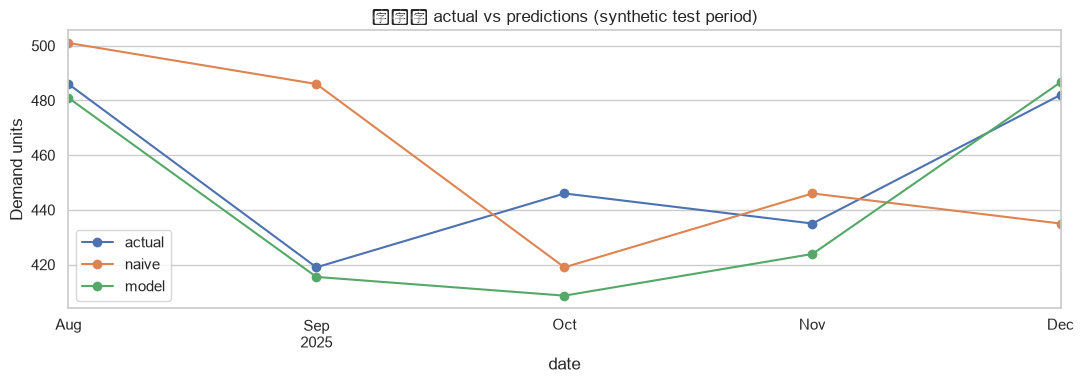

In [8]:
# 本格目的：用測試資料的 MAE、RMSE、R² 判斷模型是否值得採用
def regression_metrics(actual, predicted, name):
    return {
        "model": name,
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": mean_squared_error(actual, predicted) ** 0.5,
        "R2": r2_score(actual, predicted),
    }

metrics = pd.DataFrame([
    regression_metrics(y_test, test_df["naive_prediction"], "Naive: previous month"),
    regression_metrics(y_test, test_df["model_prediction"], "Linear regression"),
])
display(metrics.round(3))

plot_df = test_df.groupby("date", as_index=False).agg(
    actual=("demand_units", "sum"),
    naive=("naive_prediction", "sum"),
    model=("model_prediction", "sum"),
)
plot_df.plot(x="date", y=["actual", "naive", "model"], figsize=(11, 4), marker="o")
plt.title(f"{SELECTED_COMPANY} actual vs predictions (synthetic test period)")
plt.ylabel("Demand units")
plt.tight_layout()
plt.show()

#### 程式碼說明（繁體中文）

- **這段做了什麼：** 以相同測試集比較簡單基準和線性迴歸，並將各商品預測加總成月圖。
- **預期輸出：** 兩列模型指標與實際／預測折線圖。
- **完成檢核：** 若線性迴歸 MAE 較高，結論應是目前不值得取代簡單基準。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D1-S09] 執行透明的市場訊號情境模擬

In [9]:
# 本格目的：只改變一個可見假設，觀察模型預測如何改變
latest = company_df.sort_values("date").groupby("offer", as_index=False).tail(1).copy()
base_pred = np.maximum(0, model.predict(latest[numeric_features + categorical_features]))
scenario = latest.copy()
scenario["search_index"] = np.minimum(100, scenario["search_index"] * 1.10)
scenario_pred = np.maximum(0, model.predict(scenario[numeric_features + categorical_features]))

scenario_result = latest[["offer", "search_index"]].copy()
scenario_result["base_prediction"] = base_pred
scenario_result["search_plus_10pct_prediction"] = scenario_pred
scenario_result["prediction_change"] = scenario_pred - base_pred
scenario_result["warning"] = "虛擬關聯情境；不是因果效果"
display(scenario_result.round(2))

,offer,search_index,base_prediction,search_plus_10pct_prediction,prediction_change,warning
47,羊毛氈課程,64.600,116.670,118.570,1.910,虛擬關聯情境；不是因果效果
23,手捏陶體驗,56.000,106.620,108.270,1.650,虛擬關聯情境；不是因果效果
71,金工入門,81.400,131.000,133.400,2.400,虛擬關聯情境；不是因果效果
95,老宅夜間工藝,86.100,132.320,134.870,2.540,虛擬關聯情境；不是因果效果


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 把搜尋指數提高 10% 作為透明情境，保持其他欄位不變後比較預測。
- **預期輸出：** 每個商品的基準與情境預測差。
- **完成檢核：** 表格保留非因果警語；不得說提高搜尋一定會帶來同幅需求。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

### [D1-S10] 產出企業需求決策卡並完成驗收

In [10]:
# 本格目的：把分析結果整理成可交付、可追溯的短表
best_model_row = metrics.sort_values("MAE").iloc[0]
decision_card = pd.DataFrame({
    "item": ["企業", "較佳測試方法", "測試 MAE", "建議行動", "限制", "下一步資料"],
    "content": [
        SELECTED_COMPANY,
        best_model_row["model"],
        f"{best_model_row['MAE']:.2f} 需求單位",
        "先以小規模測試驗證需求，不直接依虛擬預測大量備貨／排班。",
        "資料為虛擬且僅呈現關聯；未納入真實容量、價格實驗與競爭事件。",
        "取得至少 12 個月真實銷售／報名、價格、促銷與缺貨紀錄後回測。",
    ],
})
display(decision_card)
decision_card.to_csv(OUTPUT_DIR / "Day1_需求決策卡.csv", index=False, encoding="utf-8-sig")

,item,content
0,企業,雜草町
1,較佳測試方法,Linear regression
2,測試 MAE,6.32 需求單位
3,建議行動,先以小規模測試驗證需求，不直接依虛擬預測大量備貨／排班。
4,限制,資料為虛擬且僅呈現關聯；未納入真實容量、價格實驗與競爭事件。
5,下一步資料,取得至少 12 個月真實銷售／報名、價格、促銷與缺貨紀錄後回測。


#### 程式碼說明（繁體中文）

- **這段做了什麼：** 自動帶入較低 MAE 的方法，建立包含行動、限制與下一步資料的決策卡。
- **預期輸出：** 六列決策卡並輸出 CSV。
- **完成檢核：** 建議未把虛擬資料描述成企業真實事實。
- **可修改處：** 只修改有 `TODO` 標記的參數；其他程式先完整執行，再觀察結果。

## 當日學習驗收

> 請先獨立作答；本 Notebook 不顯示答案。答案與解析收錄於教師版題庫。

### 第 1 題

進行市場需求預測前，最先要確認的是什麼？

- A. 先挑最複雜模型
- B. 先定義要預測的需求指標與決策
- C. 先刪除所有離群值
- D. 先提高圖表解析度

### 第 2 題

測試集的主要用途為何？

- A. 反覆調整模型
- B. 補足缺失值
- C. 評估模型對未見資料的表現
- D. 增加樣本列數

### 第 3 題

時間型資料切分最合理的做法是？

- A. 將未來資料放進訓練集
- B. 依時間先後切分
- C. 只保留旺季
- D. 每月隨機刪除一半

### 第 4 題

MAE 代表什麼？

- A. 平均絕對預測誤差
- B. 模型解釋變異比例
- C. 資料筆數
- D. 平均廣告成本

### 第 5 題

若訓練誤差很低、測試誤差很高，最可能是？

- A. 資料標準化成功
- B. 模型過度配適
- C. 需求一定上升
- D. 模型沒有任何變數

### 第 6 題

相關係數高可以直接證明因果嗎？

- A. 可以
- B. 只有負相關可以
- C. 不可以
- D. 樣本超過 30 就可以

### 第 7 題

本課虛擬資料中的 demand_units 是什麼？

- A. 企業真實銷售量
- B. 為教學建立的模擬需求量
- C. 政府統計
- D. 固定不變的常數

### 第 8 題

R² 為負值可能表示什麼？

- A. 模型比以平均值預測還差
- B. 資料一定造假
- C. 模型完美
- D. 需求為負數

### 第 9 題

哪一項最能降低資料洩漏風險？

- A. 切分前用全部資料決定未來特徵
- B. 將前處理放入只用訓練資料擬合的流程
- C. 把測試答案加入特徵
- D. 只報訓練分數

### 第 10 題

向企業報告預測結果時，必須同時呈現什麼？

- A. 只有最好看的圖
- B. 誤差、假設與可執行決策
- C. 模型名稱越多越好
- D. 只呈現最高預測值

## 實作題

選擇一家公司，完成時間切分的需求預測，交付 1 張實際值－預測值圖、3 個評估指標，以及 150 字內的企業建議。建議必須包含資料為虛擬、至少一項限制與下一步驗證。

### 評分規準

- 流程可重跑（20 分）：能由載入、清理、切分到預測完整執行
- 評估正確（25 分）：MAE、RMSE、R² 計算與單位正確
- 視覺與解讀（20 分）：圖表標示清楚且不把關聯寫成因果
- 企業建議（25 分）：建議可執行並連到企業命題
- 限制與倫理（10 分）：清楚標示虛擬資料與不足

### 繳交前檢查

- 由上到下 Restart and Run All 無錯誤。
- 所有圖表、指標與結論均顯示所選企業。
- 結論明示虛擬資料、限制與下一步驗證。
- 未將預測、相關或分群寫成因果證明。